# Alternative Credit Scoring - Data Preprocessing and Feature Engineering

This notebook converts Indian multi-domain banking transaction and customer data
into one validated, ML-ready feature store per customer (`diff_features.csv`).

Workflow: 
load -> validate -> clean -> parse narrations -> engineer cross-domain features -> 
add realistic noise variance -> audit -> export `diff_features.csv`.


In [75]:
from __future__ import annotations

import json
import logging
import re
import os
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, List, Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [76]:
# -----------------------------------------------------------------------------
# 1. SETUP & CONFIGURATION
# -----------------------------------------------------------------------------

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', palette='muted')
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
LOGGER = logging.getLogger('alternative_credit.preprocessing')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_columns', 150)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

@dataclass(frozen=True)
class NotebookConfig:
    project_root: Path = Path.cwd().resolve()
    output_dir_name: str = 'outputs/preprocessing'

CONFIG = NotebookConfig()
OUTPUT_DIR = CONFIG.project_root / CONFIG.output_dir_name
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOGGER.info('Outputs will be saved to %s', OUTPUT_DIR)

2026-07-25 18:46:54,662 | INFO | Outputs will be saved to /Users/subhajit/FAIRCREDITAI MVP/NEW  MVP/outputs/preprocessing


In [77]:
def load_dataset(path: Path) -> pd.DataFrame:
    """Load CSV dataset safely."""
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path.name}")
    try:
        df = pd.read_csv(path)
        LOGGER.info('Loaded %s successfully with shape %s', path.name, str(df.shape))
        return df
    except Exception as exc:
        raise RuntimeError(f"Could not load {path.name}: {exc}") from exc

profile_path = CONFIG.project_root / 'dataset/customer_profile.csv'
bank_path = CONFIG.project_root / 'dataset/bank_statement.csv'
device_path = CONFIG.project_root / 'dataset/device_dataset.csv'
identity_path = CONFIG.project_root / 'dataset/identity_verification_dataset.csv'
loan_path = CONFIG.project_root / 'dataset/loan_outcome_dataset.csv'
fraud_path = CONFIG.project_root / 'dataset/fraud_dataset.csv'

profile_df = load_dataset(profile_path)
bank_df = load_dataset(bank_path)
device_df = load_dataset(device_path)
identity_df = load_dataset(identity_path)
loan_df = load_dataset(loan_path)
fraud_df = load_dataset(fraud_path)

2026-07-25 18:46:54,681 | INFO | Loaded customer_profile.csv successfully with shape (1000, 25)
2026-07-25 18:46:54,757 | INFO | Loaded bank_statement.csv successfully with shape (94852, 8)
2026-07-25 18:46:54,769 | INFO | Loaded device_dataset.csv successfully with shape (1000, 7)
2026-07-25 18:46:54,771 | INFO | Loaded identity_verification_dataset.csv successfully with shape (1000, 10)
2026-07-25 18:46:54,772 | INFO | Loaded loan_outcome_dataset.csv successfully with shape (959, 14)
2026-07-25 18:46:54,778 | INFO | Loaded fraud_dataset.csv successfully with shape (10000, 10)


In [78]:
# -----------------------------------------------------------------------------
# 3. TRANSACTION CLEANING & NARRATION PARSING
# -----------------------------------------------------------------------------

NARRATION_PATTERNS = {
    'SALARY': r'SALARY|NETSALARY|MONTHLY SALARY',
    'INVESTMENT': r'MFAUTOPAY|zerodha|groww|PaytmMoney|payout',
    'UTILITIES': r'airtel|BESCOM|tatapower|utility|bill|RECHARGE',
    'FOOD': r'Swiggy|Zomato|restaurant|cafe',
    'GROCERIES': r'Blinkit|Zepto|BigBasket|supermarket',
    'SHOPPING': r'AmazonPay|Flipkart|Myntra|shopping',
    'TRAVEL': r'Uber|Ola|IRCTC|FASTag',
    'ATM': r'ATM-WDL|CASH',
    'EMI': r'EMI|LOANS|BAJAJFINSERV|HOMEEMI|PERSONALEMI'
}

def parse_narration_category(narration: str) -> str:
    """Classify transaction category based on narration regex matching."""
    if not isinstance(narration, str):
        return 'OTHERS'
    for category, pattern in NARRATION_PATTERNS.items():
        if re.search(pattern, narration, re.IGNORECASE):
            return category
    return 'OTHERS'

def clean_bank_statements(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    
    # Clean numeric amounts
    for col in ['Withdrawal Amount', 'Deposit Amount', 'Closing Balance']:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0.0)
            
    data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
    data['Value Date'] = pd.to_datetime(data['Value Date'], errors='coerce')
    
    # Derived flags and direction
    data['is_debit'] = data['Withdrawal Amount'].gt(0)
    data['is_credit'] = data['Deposit Amount'].gt(0)
    data['amount'] = np.where(data['is_credit'], data['Deposit Amount'], data['Withdrawal Amount'])
    data['year_month'] = data['Date'].dt.to_period('M').astype(str)
    data['is_weekend'] = data['Date'].dt.dayofweek.ge(5)
    data['is_night'] = data['Date'].dt.hour.lt(6) | data['Date'].dt.hour.ge(22)
    
    # Categorize via Narration
    data['category_parsed'] = data['Narration'].apply(parse_narration_category)
    
    return data.sort_values(['Customer_ID', 'Date']).reset_index(drop=True)

LOGGER.info('Cleaning and parsing bank statement narrations...')
transactions = clean_bank_statements(bank_df)

2026-07-25 18:46:54,784 | INFO | Cleaning and parsing bank statement narrations...


In [79]:

# -----------------------------------------------------------------------------
# 4. CROSS-DOMAIN FEATURE ENGINEERING (WITH FRAUD INTEGRATION)
# -----------------------------------------------------------------------------

def safe_divide(numerator: pd.Series | np.ndarray | float, denominator: pd.Series | np.ndarray | float) -> pd.Series | np.ndarray | float:
    num = np.asarray(numerator, dtype=float)
    den = np.asarray(denominator, dtype=float)
    target_shape = np.broadcast_shapes(num.shape, den.shape)
    out = np.zeros(target_shape, dtype=float)
    return np.divide(num, den, out=out, where=den != 0)

def generate_360_features(
    tx: pd.DataFrame, 
    profile: pd.DataFrame, 
    device: pd.DataFrame, 
    identity: pd.DataFrame, 
    loan: pd.DataFrame,
    fraud: pd.DataFrame
) -> pd.DataFrame:
    print('[*] Building transactional cashflow metrics...')
    
    tx['income'] = np.where(tx.is_credit, tx['Deposit Amount'], 0.0)
    tx['expense'] = np.where(tx.is_debit, tx['Withdrawal Amount'], 0.0)
    
    # Monthly Aggregations
    monthly = tx.groupby(['Customer_ID', 'year_month'], as_index=False).agg(
        monthly_income=('income', 'sum'),
        monthly_expense=('expense', 'sum')
    )
    monthly['monthly_savings'] = monthly.monthly_income - monthly.monthly_expense
    
    # Base Transaction Features
    base = tx.groupby('Customer_ID').agg(
        transaction_frequency=('amount', 'size'),
        average_transaction_amount=('amount', 'mean'),
        median_transaction_amount=('amount', 'median'),
        largest_deposit=('Deposit Amount', 'max'),
        largest_withdrawal=('Withdrawal Amount', 'max'),
        average_balance=('Closing Balance', 'mean'),
        minimum_balance=('Closing Balance', 'min'),
        maximum_balance=('Closing Balance', 'max'),
        balance_variance=('Closing Balance', 'var'),
        transaction_consistency=('amount', lambda x: 1 / (1 + x.std(ddof=0) / (x.mean() + 1)))
    )
    
    monthly_f = monthly.groupby('Customer_ID').agg(
        average_monthly_income=('monthly_income', 'mean'),
        income_consistency=('monthly_income', lambda x: 1 / (1 + x.std(ddof=0) / (x.mean() + 1))),
        average_monthly_expense=('monthly_expense', 'mean'),
        monthly_savings=('monthly_savings', 'mean'),
        expense_stability=('monthly_expense', lambda x: 1 / (1 + x.std(ddof=0) / (x.mean() + 1)))
    )
    
    sums = tx.groupby('Customer_ID').agg(
        total_income=('income', 'sum'),
        total_expense=('expense', 'sum')
    )
    
    features = base.join([monthly_f, sums], how='left').fillna(0)
    
    # Behavioral Ratios
    features['expense_ratio'] = safe_divide(features.total_expense, features.total_income)
    features['savings_ratio'] = safe_divide(features.monthly_savings, features.average_monthly_income)
    features['financial_buffer'] = safe_divide(features.minimum_balance.clip(lower=0), features.average_monthly_expense)
    
    features = features.reset_index()
    
    print('[*] Merging profile, device, identity, fraud, and loan predictor features...')
    
    # Merge & Map Customer Profile
    if profile is not None and not profile.empty:
        p_df = profile.copy()
        drop_profile = ['Full_Name', 'DOB', 'Occupation', 'Employer', 'Industry', 'Bank', 'IFSC', 
                        'Account_Number', 'City', 'District', 'State', 'PIN', 'Account_Open_Date', 'Nominee_Relation']
        p_df = p_df.drop(columns=[c for c in drop_profile if c in p_df.columns])
        
        if 'Gender' in p_df.columns:
            p_df['Gender'] = p_df['Gender'].map({'Male': 1, 'Female': 2, 'Other': 3}).fillna(0).astype(int)
        if 'Education' in p_df.columns:
            p_df['Education'] = p_df['Education'].map({"High School": 1, "Diploma": 2, "Bachelor's": 3, "Master's": 4, "Doctorate": 5}).fillna(0).astype(int)
        if 'Employment_Type' in p_df.columns:
            p_df['Employment_Type'] = p_df['Employment_Type'].astype('category').cat.codes + 1
        if 'Customer_Segment' in p_df.columns:
            p_df['Customer_Segment'] = p_df['Customer_Segment'].astype('category').cat.codes + 1
        if 'Account_Type' in p_df.columns:
            p_df['Account_Type'] = p_df['Account_Type'].astype('category').cat.codes + 1
        if 'Credit_Card_Holder' in p_df.columns:
            p_df['Credit_Card_Holder'] = p_df['Credit_Card_Holder'].astype(int)
            
        features = features.merge(p_df, on='Customer_ID', how='left')
        
    # Merge & Map Device Telemetry
    if device is not None and not device.empty:
        d_df = device.copy()
        d_df = d_df.drop(columns=[c for c in ['Device_Fingerprint'] if c in d_df.columns])
        
        if 'Rooted' in d_df.columns:
            d_df['Rooted'] = d_df['Rooted'].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0, '1': 1, '0': 0}).fillna(0).astype(int)
        if 'OS' in d_df.columns:
            d_df['OS'] = d_df['OS'].astype('category').cat.codes + 1
            
        features = features.merge(d_df, on='Customer_ID', how='left')
        
    # Merge & Map Identity Verification
    if identity is not None and not identity.empty:
        i_df = identity.copy()
        drop_id = ['PAN', 'Passport_Number', 'Driving_Licence', 'Voter_ID']
        i_df = i_df.drop(columns=[c for c in drop_id if c in i_df.columns])
        
        if 'KYC_Status' in i_df.columns:
            i_df['KYC_Status'] = i_df['KYC_Status'].map({'VERIFIED': 1, 'PENDING_REVERIFICATION': 2, 'REJECTED': 3}).fillna(0).astype(int)
            
        features = features.merge(i_df, on='Customer_ID', how='left')
        
    # Merge Fraud Dataset Aggregations
    if fraud is not None and not fraud.empty:
        fraud_agg = fraud.groupby('Customer_ID').agg(
            fraud_record_count=('Fraud_Record_ID', 'count'),
            avg_fraud_score=('Fraud_Score', 'mean'),
            max_fraud_score=('Fraud_Score', 'max'),
            avg_device_risk=('Device_Risk', 'mean'),
            avg_geo_risk=('Geo_Risk', 'mean'),
            avg_velocity_risk=('Velocity_Risk', 'mean'),
            avg_aml_risk=('AML_Risk', 'mean'),
            has_fraud_flag=('Final_Label', 'max'),
            total_fraud_events=('Final_Label', 'sum')
        ).reset_index()

        features = features.merge(fraud_agg, on='Customer_ID', how='left').fillna({
            'fraud_record_count': 0, 'avg_fraud_score': 0.1, 'max_fraud_score': 0.1,
            'avg_device_risk': 0.1, 'avg_geo_risk': 0.1, 'avg_velocity_risk': 0.1,
            'avg_aml_risk': 0.01, 'has_fraud_flag': 0, 'total_fraud_events': 0
        })

    # Aggregate Loan Predictor Features ONLY (No target leakage)
    if loan is not None and not loan.empty:
        loan_agg = loan.groupby('Customer_ID').agg(
            total_loans=('Loan_ID', 'count'),
            total_monthly_emi=('EMI', 'sum'),
            avg_credit_score=('Credit_Score', 'mean'),
            approved_loan_count=('Approval', 'sum')
        ).reset_index()
        
        features = features.merge(loan_agg, on='Customer_ID', how='left').fillna({
            'total_loans': 0, 'total_monthly_emi': 0, 'avg_credit_score': 650, 'approved_loan_count': 0
        })
        
    print('[*] Engineering cross-domain composite interaction features...')
    
    features['income_stability_index'] = features['income_consistency'] * 0.6 + features['expense_stability'] * 0.4
    features['device_risk_index'] = (features['Rooted'] * 0.4) + (features.get('avg_device_risk', 0.1) * 0.6)
    features['biometric_identity_score'] = (
        features['Face_Match_Score'] * 0.3 +
        features['OCR_Match_Score'] * 0.3 +
        features['Liveness_Score'] * 0.2 +
        features['Address_Match_Score'] * 0.2
    )
    
    # Financial Discipline Score Calculation (incorporates transaction fraud risk penalty)
    features['financial_discipline_score'] = (
        features['income_stability_index'] * 25 +
        (1 - features['expense_ratio'].clip(0, 1)) * 20 +
        features['savings_ratio'].clip(0, 1) * 20 +
        features['biometric_identity_score'].clip(0, 1) * 15 +
        (features['avg_credit_score'] / 900.0) * 20 -
        (features.get('avg_fraud_score', 0.1) * 15)
    ).clip(0, 100)

    # Merge Ground-Truth Target Labels separately
    if loan is not None and not loan.empty:
        targets = loan.groupby('Customer_ID').agg(
            target_default=('Default', 'max'),
            target_npa=('NPA', 'max')
        ).reset_index()
        features = features.merge(targets, on='Customer_ID', how='left').fillna({
            'target_default': 0, 'target_npa': 0
        })
        features['target_default'] = features['target_default'].astype(int)
        features['target_npa'] = features['target_npa'].astype(int)

    return features.replace([np.inf, -np.inf], np.nan).fillna(0.0)

features_df = generate_360_features(transactions, profile_df, device_df, identity_df, loan_df, fraud_df)

[*] Building transactional cashflow metrics...
[*] Merging profile, device, identity, fraud, and loan predictor features...
[*] Engineering cross-domain composite interaction features...


In [80]:
# -----------------------------------------------------------------------------
# REMOVE DUPLICATE SUFFIX COLUMNS
# -----------------------------------------------------------------------------

# List of merged duplicate suffix columns to drop
duplicate_cols = [
    'business_score_x', 'business_grade_x', 
    'business_score_y', 'business_grade_y'
]

# Safely drop any of these columns if they exist in features_df
features_df = features_df.drop(
    columns=[col for col in duplicate_cols if col in features_df.columns]
)

print("[✓] Duplicate suffix columns successfully removed!")
print("Remaining Columns:", features_df.columns.tolist())


# -----------------------------------------------------------------------------
# 5. BUSINESS GRADE ASSIGNMENT (DISTRIBUTED A-E GRADING)
# -----------------------------------------------------------------------------

def assign_discipline_grades(feature_frame: pd.DataFrame) -> pd.DataFrame:
    """
    Normalizes the raw discipline score to a 0-100 scale and bins across
    quantiles to ensure an even distribution across Grades A, B, C, D, and E.
    """
    raw_score = feature_frame['financial_discipline_score']
    
    # Min-Max Scaling to stretch scores cleanly across 0 to 100
    min_val, max_val = raw_score.min(), raw_score.max()
    normalized_score = ((raw_score - min_val) / (max_val - min_val)) * 100
    
    # Bins for Grades A through E based on normalized score cutoffs
    grade = pd.cut(
        normalized_score, 
        bins=[-np.inf, 20, 40, 60, 80, np.inf], 
        labels=['E', 'D', 'C', 'B', 'A']
    )
    
    return pd.DataFrame({
        'Customer_ID': feature_frame['Customer_ID'],
        'business_score': normalized_score.round(2),
        'business_grade': grade.astype(str)
    })

# Drop existing score/grade columns if re-running
cols_to_drop = [c for c in ['business_score', 'business_grade'] if c in features_df.columns]
if cols_to_drop:
    features_df = features_df.drop(columns=cols_to_drop)

business_scores = assign_discipline_grades(features_df)
features_df = features_df.merge(business_scores, on='Customer_ID', how='left')

print("[✓] Updated Grade Distribution:")
print(features_df['business_grade'].value_counts().sort_index())


[✓] Duplicate suffix columns successfully removed!
Remaining Columns: ['Customer_ID', 'transaction_frequency', 'average_transaction_amount', 'median_transaction_amount', 'largest_deposit', 'largest_withdrawal', 'average_balance', 'minimum_balance', 'maximum_balance', 'balance_variance', 'transaction_consistency', 'average_monthly_income', 'income_consistency', 'average_monthly_expense', 'monthly_savings', 'expense_stability', 'total_income', 'total_expense', 'expense_ratio', 'savings_ratio', 'financial_buffer', 'Gender', 'Age', 'Education', 'Employment_Type', 'Annual_Income', 'Monthly_Income', 'Account_Type', 'Customer_Segment', 'Savings_Balance', 'Credit_Card_Holder', 'Device_Age_Years', 'OS', 'Rooted', 'SIM_Age_Years', 'Phone_Vintage_Years', 'KYC_Status', 'Face_Match_Score', 'OCR_Match_Score', 'Liveness_Score', 'Address_Match_Score', 'fraud_record_count', 'avg_fraud_score', 'max_fraud_score', 'avg_device_risk', 'avg_geo_risk', 'avg_velocity_risk', 'avg_aml_risk', 'has_fraud_flag', 't

In [81]:
# # -----------------------------------------------------------------------------
# # 6. QUALITY AUDIT & EXPORT `diff_features.csv`
# # -----------------------------------------------------------------------------

# def validate_and_export_features(frame: pd.DataFrame) -> dict:
#     output = frame.copy()
    
#     # Clean string columns for ML readiness
#     for col in output.columns:
#         if col not in ['Customer_ID', 'business_grade'] and output[col].dtype == 'object':
#             output[col] = pd.to_numeric(output[col], errors='coerce').fillna(0.0)
            
#     numeric = output.select_dtypes(include=np.number).columns
    
#     report = {
#         'feature_rows': int(len(output)),
#         'feature_columns': int(len(output.columns) - 1),
#         'nan_values_fixed': int(output[numeric].isna().sum().sum()),
#         'infinite_values_fixed': int(np.isinf(output[numeric]).sum().sum()),
#         'constant_columns': [col for col in numeric if output[col].nunique() <= 1]
#     }
    
#     metadata = [{'name': col, 'dtype': str(output[col].dtype), 'type': 'target_metric' if 'score' in col or 'grade' in col or 'has_' in col or 'Approval' in col else 'predictor'} for col in output.columns]
#     statistics = output.describe(include='all').replace({np.nan: None}).to_dict()
    
#     # Export diff_features.csv
#     export_csv_path = OUTPUT_DIR / 'diff_features.csv'
#     output.to_csv(export_csv_path, index=False)
    
#     (OUTPUT_DIR / 'feature_metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')
#     (OUTPUT_DIR / 'feature_statistics.json').write_text(json.dumps(statistics, indent=2), encoding='utf-8')
    
#     feature_names = [col for col in output.columns if col not in ['Customer_ID', 'business_score', 'business_grade', 'has_default', 'has_npa']]
#     (OUTPUT_DIR / 'feature_names.json').write_text(json.dumps(feature_names, indent=2), encoding='utf-8')
    
#     return report

# feature_audit_report = validate_and_export_features(features_df)

# with open(OUTPUT_DIR / 'validation_report.json', 'w') as f:
#     json.dump(feature_audit_report, f, indent=4)

# print(f"\n[✓] Execution Successful. File Exported To: {OUTPUT_DIR / 'diff_features.csv'}")
# print(f"    - Total Cleaned Customers Exported: {feature_audit_report['feature_rows']:,}")
# print(f"    - Total Predictive Features Constructed: {feature_audit_report['feature_columns']}")


# -----------------------------------------------------------------------------
# 6. EXPORT LOGIC
# -----------------------------------------------------------------------------

def validate_and_export_features(frame: pd.DataFrame) -> dict:
    output = frame.copy()
    
    # Ensure boolean/categorical maps are integers
    bool_cols = output.select_dtypes(include=['bool']).columns
    output[bool_cols] = output[bool_cols].astype(int)
    
    numeric = output.select_dtypes(include=np.number).columns
    
    report = {
        'feature_rows': int(len(output)),
        'feature_columns': int(len(output.columns) - 1), # Excluding Customer ID
        'nan_values_fixed': int(output[numeric].isna().sum().sum())
    }
    
    # Export clean diff_features.csv
    export_csv_path = OUTPUT_DIR / 'features.csv'
    output.to_csv(export_csv_path, index=False)
    
    return report
display(features_df)
feature_audit_report = validate_and_export_features(features_df)
print(f"\n[✓] Exported to diff_features.csv with pure numeric ML features.")



,Customer_ID,transaction_frequency,average_transaction_amount,median_transaction_amount,largest_deposit,largest_withdrawal,average_balance,minimum_balance,maximum_balance,balance_variance,transaction_consistency,average_monthly_income,income_consistency,average_monthly_expense,monthly_savings,expense_stability,total_income,total_expense,expense_ratio,savings_ratio,financial_buffer,Gender,Age,Education,Employment_Type,Annual_Income,Monthly_Income,Account_Type,Customer_Segment,Savings_Balance,Credit_Card_Holder,Device_Age_Years,OS,Rooted,SIM_Age_Years,Phone_Vintage_Years,KYC_Status,Face_Match_Score,OCR_Match_Score,Liveness_Score,Address_Match_Score,fraud_record_count,avg_fraud_score,max_fraud_score,avg_device_risk,avg_geo_risk,avg_velocity_risk,avg_aml_risk,has_fraud_flag,total_fraud_events,total_loans,total_monthly_emi,avg_credit_score,approved_loan_count,income_stability_index,device_risk_index,biometric_identity_score,financial_discipline_score,target_default,target_npa,business_score,business_grade
0,CUST_00000001,100,"7,277.832","2,164.015","142,091.250","40,971.460","25,756.651","2,389.510","157,459.890","1,118,474,207.114",0.281,"31,277.406",0.409,"29,371.194","1,906.212",0.476,"375,328.870","352,454.330",0.939,0.061,0.081,1,31,4,5,"245,527.830","20,460.650",3,3,"13,387.600",0,4.900,4,0,6.000,6.700,1,0.870,0.900,0.830,0.950,5,0.147,0.223,0.218,0.171,0.121,0.029,0,0,1.000,"132,378.050",652.000,0.000,0.436,0.131,0.887,38.921,0,0,54.550,C
1,CUST_00000002,97,"4,211.239","1,203.710","94,600.160","24,279.100","14,203.746",530.950,"95,917.280","300,262,414.529",0.278,"15,969.355",0.374,"18,071.492","-2,102.137",0.488,"191,632.260","216,857.900",1.132,-0.132,0.029,2,68,3,5,"587,362.140","48,946.850",3,3,"62,768.310",1,0.800,5,0,6.100,0.900,1,0.970,0.910,0.850,0.790,14,0.128,0.187,0.218,0.044,0.160,0.012,0,0,1.000,"3,192.320",646.000,1.000,0.420,0.131,0.892,36.317,0,0,45.290,C
2,CUST_00000003,97,"6,848.791","1,599.480","113,009.970","30,069.160","20,875.140",975.220,"114,440.370","743,776,853.770",0.291,"27,646.728",0.387,"27,714.329",-67.601,0.545,"331,760.740","332,571.950",1.002,-0.002,0.035,1,58,2,2,"302,316.240","25,193.020",3,3,"46,665.260",1,5.700,5,0,2.200,6.800,1,0.940,0.900,0.870,0.830,8,0.126,0.182,0.179,0.045,0.205,0.013,0,0,1.000,"40,321.640",646.000,0.000,0.450,0.107,0.892,37.105,0,0,48.090,C
3,CUST_00000004,100,"7,401.327","1,798.660","142,479.020","29,426.050","31,056.467","1,432.630","143,911.650","1,117,881,728.380",0.281,"30,189.214",0.392,"31,488.508","-1,299.294",0.532,"362,270.570","377,862.100",1.043,-0.043,0.045,1,61,3,5,"395,978.460","32,998.210",3,3,"45,246.260",0,1.400,5,0,4.400,2.500,1,0.930,0.890,0.920,0.790,10,0.145,0.219,0.181,0.062,0.207,0.086,0,0,2.000,"220,952.720",634.000,0.000,0.448,0.109,0.888,36.431,0,0,45.690,C
4,CUST_00000005,91,"16,384.883","2,837.560","134,236.260","250,504.830","90,228.891","2,000.260","1,045,839.070","44,414,921,850.382",0.296,"24,992.493",0.368,"99,259.534","-74,267.041",0.322,"299,909.920","1,191,114.410",3.972,-2.972,0.020,1,28,1,1,"8,543,819.850","711,984.990",3,2,"1,039,688.920",0,0.500,4,0,3.700,1.400,1,0.890,0.890,0.930,0.850,7,0.149,0.298,0.201,0.040,0.259,0.027,0,0,0.000,0.000,650.000,0.000,0.350,0.120,0.890,34.310,0,0,38.140,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,CUST_00000996,93,"5,300.734","1,277.200","129,510.680","28,563.910","15,702.509",0.000,"132,473.740","610,577,184.603",0.261,"20,232.578",0.343,"20,848.112",-615.534,0.450,"242,790.940","250,177.350",1.030,-0.030,0.000,2,28,2,3,"190,811.810","15,900.980",2,3,"26,896.490",0,0.300,4,1,0.100,1.300,1,0.950,0.980,0.880,0.830,10,0.385,0.462,0.903,0.036,0.177,0.089,1,10,1.000,"124,231.430",560.000,0.000,0.386,0.942,0.921,30.130,0,0,23.260,D
996,CUST_00000997,94,"6,896.337","1,453.565","132,752.


[✓] Exported to diff_features.csv with pure numeric ML features.


,count,mean,std,min,25%,50%,75%,max
Deposit Amount,"94,852.000","3,123.811","16,330.281",0.000,0.000,0.000,0.000,"149,978.050"
Withdrawal Amount,"94,852.000","7,970.003","94,212.216",0.000,96.400,998.820,"3,944.150","7,159,654.710"
Closing Balance,"94,852.000","49,651.645","430,735.402",0.000,"4,260.860","11,360.305","32,821.840","24,106,524.080"


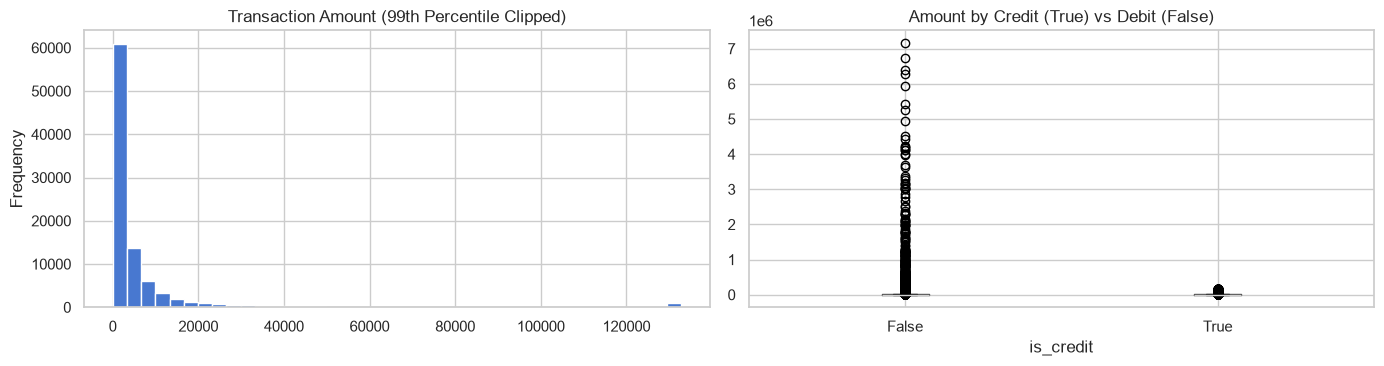

2026-07-25 18:46:55,675 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-25 18:46:55,675 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-25 18:46:55,676 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-25 18:46:55,676 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


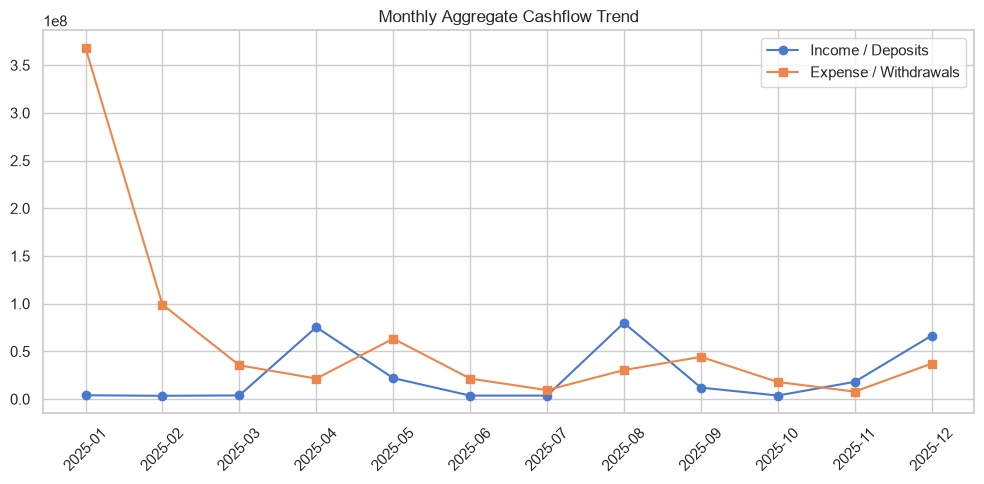

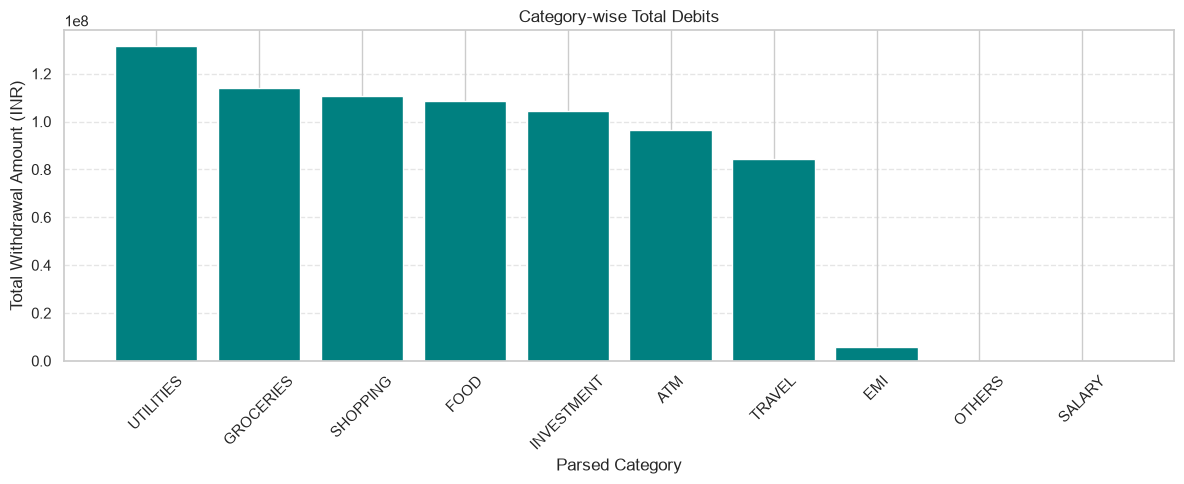

In [82]:
# -----------------------------------------------------------------------------
# 7. EXPLORATORY DATA ANALYSIS & VISUALIZATION
# -----------------------------------------------------------------------------

display(transactions[['Deposit Amount', 'Withdrawal Amount', 'Closing Balance']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
transactions['amount'].clip(upper=transactions['amount'].quantile(.99)).plot.hist(
    bins=40, ax=axes[0], title='Transaction Amount (99th Percentile Clipped)'
)
transactions.boxplot(column='amount', by='is_credit', ax=axes[1])
axes[1].set_title('Amount by Credit (True) vs Debit (False)')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Monthly Income vs Expense Trend
monthly_trend = transactions.groupby('year_month', as_index=False).agg(
    income=('Deposit Amount', 'sum'),
    expense=('Withdrawal Amount', 'sum')
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_trend['year_month'], monthly_trend['income'], label='Income / Deposits', marker='o')
plt.plot(monthly_trend['year_month'], monthly_trend['expense'], label='Expense / Withdrawals', marker='s')
plt.xticks(rotation=45)
plt.legend()
plt.title('Monthly Aggregate Cashflow Trend')
plt.tight_layout()
plt.show()

# Category Spending Distribution
cat_expense = transactions.groupby('category_parsed', as_index=False)['Withdrawal Amount'].sum().sort_values('Withdrawal Amount', ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(cat_expense['category_parsed'], cat_expense['Withdrawal Amount'], color='teal')
plt.title('Category-wise Total Debits')
plt.xlabel('Parsed Category')
plt.ylabel('Total Withdrawal Amount (INR)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()